In [1]:
# fråga 9 kapital 2
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
df = pd.read_csv("data_01.csv")
df = pd.DataFrame(df)
print(df)

#X = df[["x1", "x2", "x3", "x4", "x5"]] #fråga Antonio om det! ( vad är skillnaden mellan dessa två? )
X = df.drop(columns=["target"])
y = df["target"]  


#c)	Dela upp datan ytterligare, i ett träning-, ett validering-, och ett testset med train_test_split().
# Låt 20% av datan vara testdata och 15% av den återstående datan vara valideringsdata.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42
)
#
print("Träning:", len(X_train), "Validering:", len(X_val), "Test:", len(X_test))


#linreg = LinearRegression() --- IGNORE ---
#tree = DecisionTreeRegressor(random_state=42) --- IGNORE --- (D)
lindreg = LinearRegression()
tree = DecisionTreeRegressor(random_state=42) # varför random_state? 42 ??
lindreg.fit(X_train, y_train)
tree.fit(X_train, y_train)


# utvärdera modellerna på valideringsdata (E)
rmse_lindreg = mean_squared_error(y_val, lindreg.predict(X_val))
rmse_tree = mean_squared_error(y_val, tree.predict(X_val))
print(rmse_lindreg, rmse_tree)



#Träna om den bäst presterande modellen på både tränings- och valideringsdatan. (F)
best_model = tree if rmse_tree < rmse_lindreg else lindreg
best_model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))

best_model.fit(X_train_full, y_train_full) 

#Utvärdera modellen på testdatan.
rmse_test = mean_squared_error(y_test, best_model.predict(X_test))
print(f"RMSE på testdata: {rmse_test:.2f}")

#h)	Träna om modellen på hela datasetet.
best_model.fit(X, y)



           x1        x2        x3        x4        x5      target
0    0.743487  1.072825  1.332911 -1.244771  0.344978  220.173943
1    0.835264  0.202184  0.966480  0.745883 -0.033773  175.873929
2   -1.103234  0.030615 -0.140385  0.727683 -2.831224 -162.270054
3    1.210186  1.685258 -0.394123  0.719024 -2.166585  165.930461
4    0.474577  0.647737 -0.451812 -0.409472 -0.051473   43.250511
..        ...       ...       ...       ...       ...         ...
194  0.506013 -1.546832  1.371920  0.365069  1.217062   48.732442
195 -0.108058  0.008594 -0.244017  0.624930  0.397292   -0.346974
196 -0.331685  0.763282 -0.046545 -2.077271 -0.441957  -30.311940
197  3.106505  1.060556 -0.709179 -1.876106  0.161476  237.660709
198 -0.628655 -0.142817 -2.219201 -2.189732  0.720388 -260.843988

[199 rows x 6 columns]
Träning: 119 Validering: 40 Test: 40
11.021600622964419 7596.571275200692
RMSE på testdata: 11.37


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [2]:
# fråga 10 kapital 2
import numpy as np
df = pd.read_csv("salary_dataset.csv")
df = pd.DataFrame(df)
print(df)
X = df.drop(columns=["Salary"])
y = df["Salary"]

#Dela upp datasetet i träning- och testset. (Inget validerings-set alltså!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#c)	Träna två regressionsmodeller	med	k-delad	korsvalidering	med cross_validate()-funktionen från scikit-learn. 
# Använd neg_root_mean_squared_error som scoring. Välj själv hur många iterationer den ska göra genom hyperparametern cv.
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVR

x ,y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
Ir = LinearRegression()
svr = LinearSVR(random_state=42)

cv_Ir = cross_validate(Ir, X_train, y_train, cv=10, scoring="neg_root_mean_squared_error")
cv_svr = cross_validate(svr, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
print("Linear Regression CV RMSE:", -np.mean(cv_Ir["test_score"]))
print("SVR CV RMSE:", -np.mean(cv_svr["test_score"]))

# Utvärdera modellen som presterar bäst på testsetet.
if -np.mean(cv_Ir["test_score"]) < -np.mean(cv_svr["test_score"]):
    print("The best model is Linear Regression")
elif -np.mean(cv_Ir["test_score"]) == -np.mean(cv_svr["test_score"]):
    print("Both models perform equally well")
else:
    print("The best model is SVR")


    YearsExperience    Salary
0               1.2   39344.0
1               1.4   46206.0
2               1.6   37732.0
3               2.1   43526.0
4               2.3   39892.0
5               3.0   56643.0
6               3.1   60151.0
7               3.3   54446.0
8               3.3   64446.0
9               3.8   57190.0
10              4.0   63219.0
11              4.1   55795.0
12              4.1   56958.0
13              4.2   57082.0
14              4.6   61112.0
15              5.0   67939.0
16              5.2   66030.0
17              5.4   83089.0
18              6.0   81364.0
19              6.1   93941.0
20              6.9   91739.0
21              7.2   98274.0
22              8.0  101303.0
23              8.3  113813.0
24              8.8  109432.0
25              9.1  105583.0
26              9.6  116970.0
27              9.7  112636.0
28             10.4  122392.0
29             10.6  121873.0
Linear Regression CV RMSE: 55.633144721497295
SVR CV RMSE: 93.43296396

In [3]:
# fråga 11 kapital 2
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

df = sns.load_dataset("mpg") 
print(df.head())
# BDroppa rader med saknade värden med dropna()-metoden.
df = df.dropna()
# c)	Droppa kolumnen name.
df = df.drop(columns=["name"])
#d)	Utför en dummy-variable-encoding på origin-kolumnen med pandas get_dummies()-funktion. 
# Ange drop_first=True så att vi får 2 nya kolumner istället för 3.

df = pd.get_dummies(df, columns=["origin"], drop_first=True)
print(df.head())

#e)	Dela upp datasetet i X och y, med mpg som den beroende variabeln y.
X = df.drop(columns=["mpg"])
y = df["mpg"]

#f)	Dela upp datasetet i träning- och testset.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Träning:", len(X_train), "Test:", len(X_test))

#g)	Träna en linjär regressionsmodell på träningsdatan och utvärdera den på testdatan.
linreg = LinearRegression()
linreg.fit(X_train, y_train)
mse = mean_squared_error(y_test, linreg.predict(X_test))
rmse = np.sqrt(mse)
print(f"RMSE på testdata: {rmse:.2f}")

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   

In [4]:
#kapital 3 

In [5]:
# fråga 14 kapital 3
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# This code is merely executed to see the description of the data in a smooth way
data = load_diabetes()
print(data.DESCR)

# Storing/loading the data the way it will be used
X, y = load_diabetes(return_X_y=True, as_frame=True)
print(X.info())
print(y.info())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



#linreg = LinearRegression() --- IGNORE ---
lindreg = LinearRegression()
# tränar modellen på träningsdata
lindreg.fit(X_train, y_train)

#prediktion
y_pred = lindreg.predict(X_test)

#utvärdering
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE på testdata: {rmse:.2f}")





.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

     Emp_Id  satisfaction_level  last_evaluation  number_project  \
0  IND02438                0.38             0.53               2   
1  IND28133                0.80             0.86               5   
2  IND07164                0.11             0.88               7   
3  IND30478                0.72             0.87               5   
4  IND24003                0.37             0.52               2   

   average_montly_hours  time_spend_company  Work_accident  left  \
0                   157                   3              0     1   
1                   262                   6              0     1   
2                   272                   4              0     1   
3                   223                   5              0     1   
4                   159                   3              0     1   

   promotion_last_5years Department  salary  
0                      0      sales     low  
1                      0      sales  medium  
2                      0      sales  medium 

Text(0.5, 0, 'avg_monthly_hours_totaly')

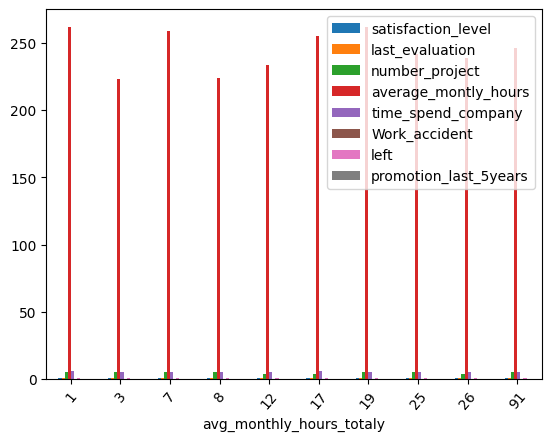

In [6]:
#execell fil uppgiften
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("hr_employee_data.xlsx")
print(df.head())

# för statisk utan att använda ML så förök att hitta medelvärde , osv. 
# för att hitta en bra gissning på hur mycket en anställd tjänar baserat på de andra kolumnerna.

# avg av average_montly_hours
mean_value = df["average_montly_hours"].mean()


# salews som har fått en befordran de senaste 5 åren
sales_1 = df[
    (df["Department"] == "sales") & (df["promotion_last_5years"] >0)]

hej = df[(df["Department"] == "sales") & (df["satisfaction_level"] > 0.5)]
hej.head(10).plot(kind='bar', rot = 50)


sales_1 = df[
    (df["Department"] == "IT") & (df["salary"] == "high")]
plt.xlabel("avg_monthly_hours_totaly")





In [24]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Läs in data
df = pd.read_csv("car_price_dataset.csv")  # byt till ditt filnamn
df = pd.DataFrame(df)
print(df.head())
# Features och target
# 1. Skapa den kodade versionen
df = df.dropna()

df_encoding = pd.get_dummies(df, drop_first=True)
X = df_encoding.drop(columns=["price"])
y = df_encoding["price"]

  Brand;Model;Year;Engine_Size;Fuel_Type;Transmission;Mileage;Doors;Owner_Count;Price
0     Kia;Rio;2020;4.2;Diesel;Manual;289944;3;5;8501                                 
1  Chevrolet;Malibu;2012;2.0;Hybrid;Automatic;535...                                 
2  Mercedes;GLA;2020;4.2;Diesel;Automatic;231440;...                                 
3  Audi;Q5;2023;2.0;Electric;Manual;160971;2;1;11780                                 
4  Volkswagen;Golf;2003;2.6;Hybrid;Semi-Automatic...                                 


KeyError: "['price'] not found in axis"